In [49]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn.datasets as datasets
from sklearn.decomposition import PCA

In [50]:
articles_df = pd.read_csv("data/nyt-frame.csv", header=0)
header = list(articles_df.columns[9:])
data = articles_df.iloc[:, 9:].values

In [51]:
sample_words = np.random.choice(header, 20, replace=False)
print("Sample dictionary words:", sample_words)

Sample dictionary words: ['minimal' 'proves' 'mug' 'impress' 'capital' 'bush' 'give' 'evoked'
 'hits' 'simplicity' 'respectively' 'kinds' 'print' 'starring' 'physical'
 'calif' 'casts' 'rush' 'monumental' 'meaning']


In [52]:
pca = PCA()
x_pca = pca.fit_transform(data)

In [53]:
pc1 = pca.components_[0]
idx_max = np.argsort(pc1)[-15:]
idx_min = np.argsort(pc1)[:15]

print(
    "Top 15 +PC1 words",
    [header[i] for i in idx_max],
)
print(
    "Top 15 -PC1 words",
    [header[i] for i in idx_min],
)

Top 15 +PC1 words ['me', 'he', 'mrs', 'im', 'paintings', 'process', 'painting', 'my', 'cooper', 'mother', 'said', 'i', 'ms', 'her', 'she']
Top 15 -PC1 words ['music', 'trio', 'theater', 'orchestra', 'composers', 'opera', 'theaters', 'm', 'program', 'players', 'festival', 'east', 'y', 'jersey', 'symphony']


In [54]:
pc2 = pca.components_[1]
idx_max = np.argsort(pc2)[-15:]
idx_min = np.argsort(pc2)[:15]

print(
    "Top 15 +PC2 words:",
    [header[i] for i in idx_max],
)
print(
    "Top 15 -PC2 words:",
    [header[i] for i in idx_min],
)

Top 15 +PC2 words: ['vocal', 'orchestra', 'songs', 'musical', 'music', 'festival', 'production', 'sang', 'hour', 'i', 'ms', 'opera', 'theater', 'she', 'her']
Top 15 -PC2 words: ['art', 'museum', 'images', 'artists', 'donations', 'museums', 'painting', 'tax', 'paintings', 'sculpture', 'gallery', 'sculptures', 'painted', 'white', 'service']


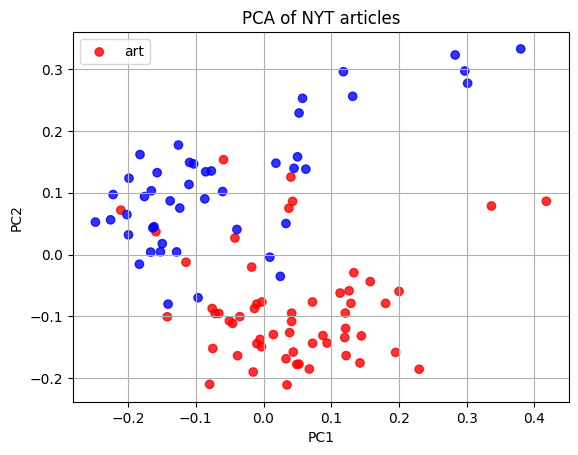

In [55]:
labels = articles_df["class.labels"].values
colors = ["red" if label == "art" else "blue" for label in labels]

plt.figure()
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=colors, alpha=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of NYT articles")
plt.legend(["art", "music"])
plt.grid()
plt.show()

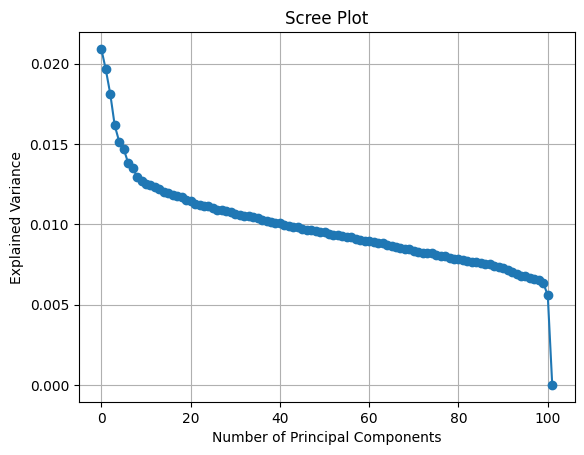

In [56]:
variance_ratio = pca.explained_variance_ratio_


plt.figure()
plt.plot(variance_ratio, marker="o")
plt.xlabel("Number of Principal Components")
plt.ylabel("Explained Variance")
plt.title("Scree Plot")
plt.grid()
plt.show()

In [57]:
cars_df = pd.read_csv("data/04cars-data.csv", header=0)

In [58]:
data = cars_df.iloc[:, 9:]
data.shape

(387, 11)

In [59]:
from sklearn import preprocessing

scaled_data = preprocessing.scale(data)

In [60]:
scaled_data.mean(axis=0)

array([-4.13106242e-17,  4.13106242e-17, -6.05889155e-16, -1.00981526e-16,
       -1.79012705e-16, -4.59006935e-18, -7.57361443e-17, -2.06553121e-16,
        7.89491929e-16, -6.70150125e-16,  1.78094691e-15])

In [61]:
scaled_data.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [62]:
pca = PCA()
X_pca = pca.fit_transform(scaled_data)
print(pca.explained_variance_ratio_)

[6.45876221e-01 1.71265888e-01 7.72480259e-02 3.24559536e-02
 2.50395994e-02 1.79948832e-02 1.27744735e-02 7.87625563e-03
 6.03527097e-03 3.36157838e-03 7.18504308e-05]


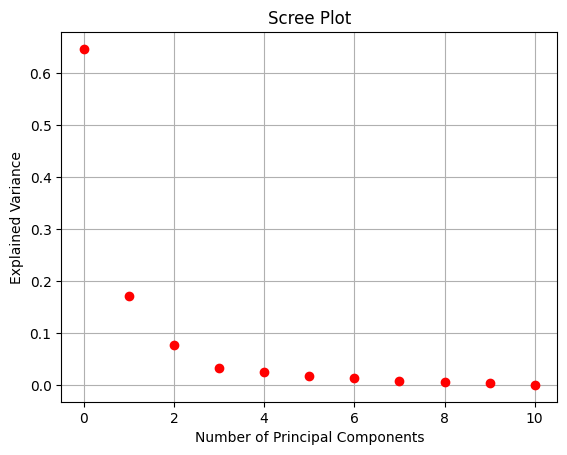

In [64]:
variance = pca.explained_variance_ratio_

plt.figure()
plt.plot(variance, "ro")
plt.xlabel("Number of Principal Components")
plt.ylabel("Explained Variance")
plt.title("Scree Plot")
plt.grid()
plt.show()

In [65]:
attributes = cars_df.columns[9:]
attributes

Index(['Retail Price', 'Dealer Cost', 'Engine Size (l)', 'Cyl', 'HP',
       'City MPG', 'Hwy MPG', 'Weight', 'Wheel Base', 'Len', 'Width'],
      dtype='str')

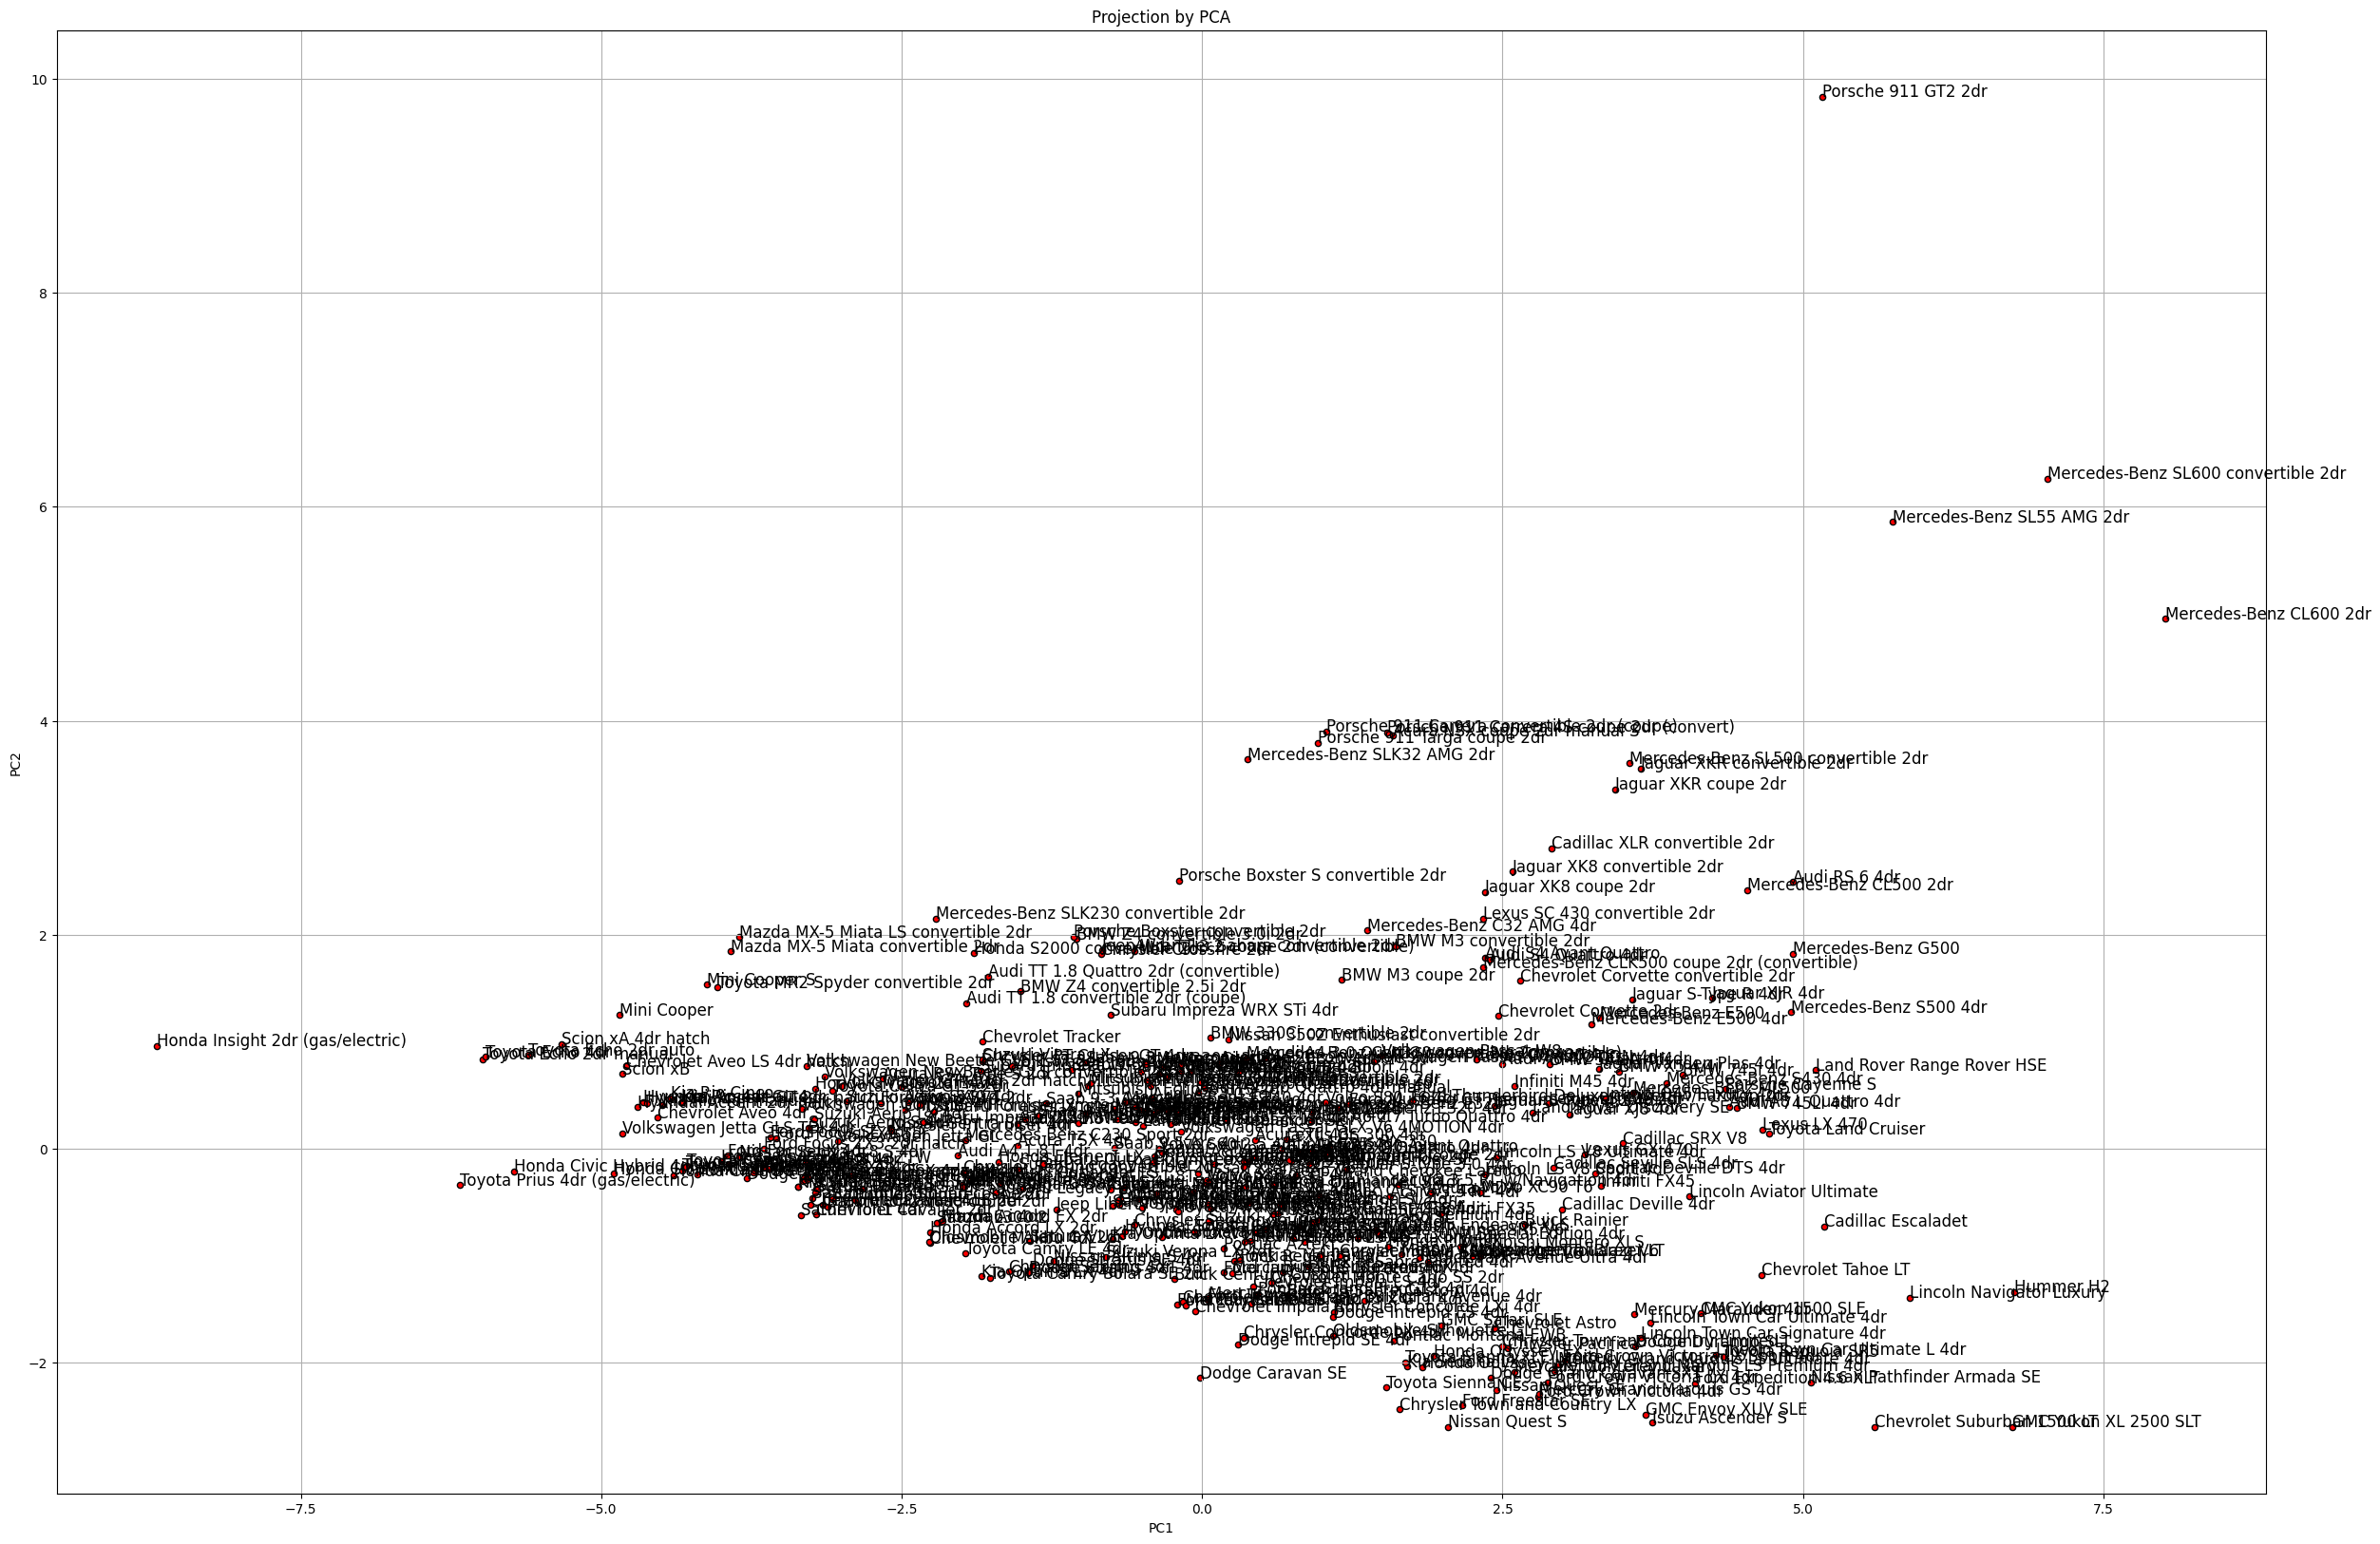

In [68]:
plt.figure(figsize=(30, 20))
x = X_pca[:, 0]
y = X_pca[:, 1]
plt.scatter(x, y, c="red", s=20, edgecolors="k")
plt.title("Projection by PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
labels = list(cars_df.iloc[:, 0])
for i, label in enumerate(labels):
    plt.annotate(label, (x[i], y[i]), fontsize=12)
plt.grid()
plt.show()

In [69]:
def biplot(score, coeff, labels=None):
    plt.figure(figsize=(25, 18))
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    xs = score[:, 0]
    ys = score[:, 1]
    n = coeff.shape[0]
    scalex = 1.0 / (xs.max() - xs.min())
    scaley = 1.0 / (ys.max() - ys.min())
    plt.scatter(xs * scalex, ys * scaley, c="red", s=20, edgecolors="k")
    for i in range(n):
        plt.arrow(0, 0, coeff[i, 0], coeff[i, 1], color="blue", alpha=0.5)
        if labels is None:
            plt.text(
                coeff[i, 0] * 1.15,
                coeff[i, 1] * 1.15,
                "Var" + str(i + 1),
                color="green",
                ha="center",
                va="center",
            )
        else:
            plt.text(
                coeff[i, 0] * 1.15,
                coeff[i, 1] * 1.15,
                labels[i],
                color="green",
                ha="center",
                va="center",
            )
    axes = plt.gca()
    axes.set_xlim([-1, 1])
    axes.set_ylim([-1, 1])

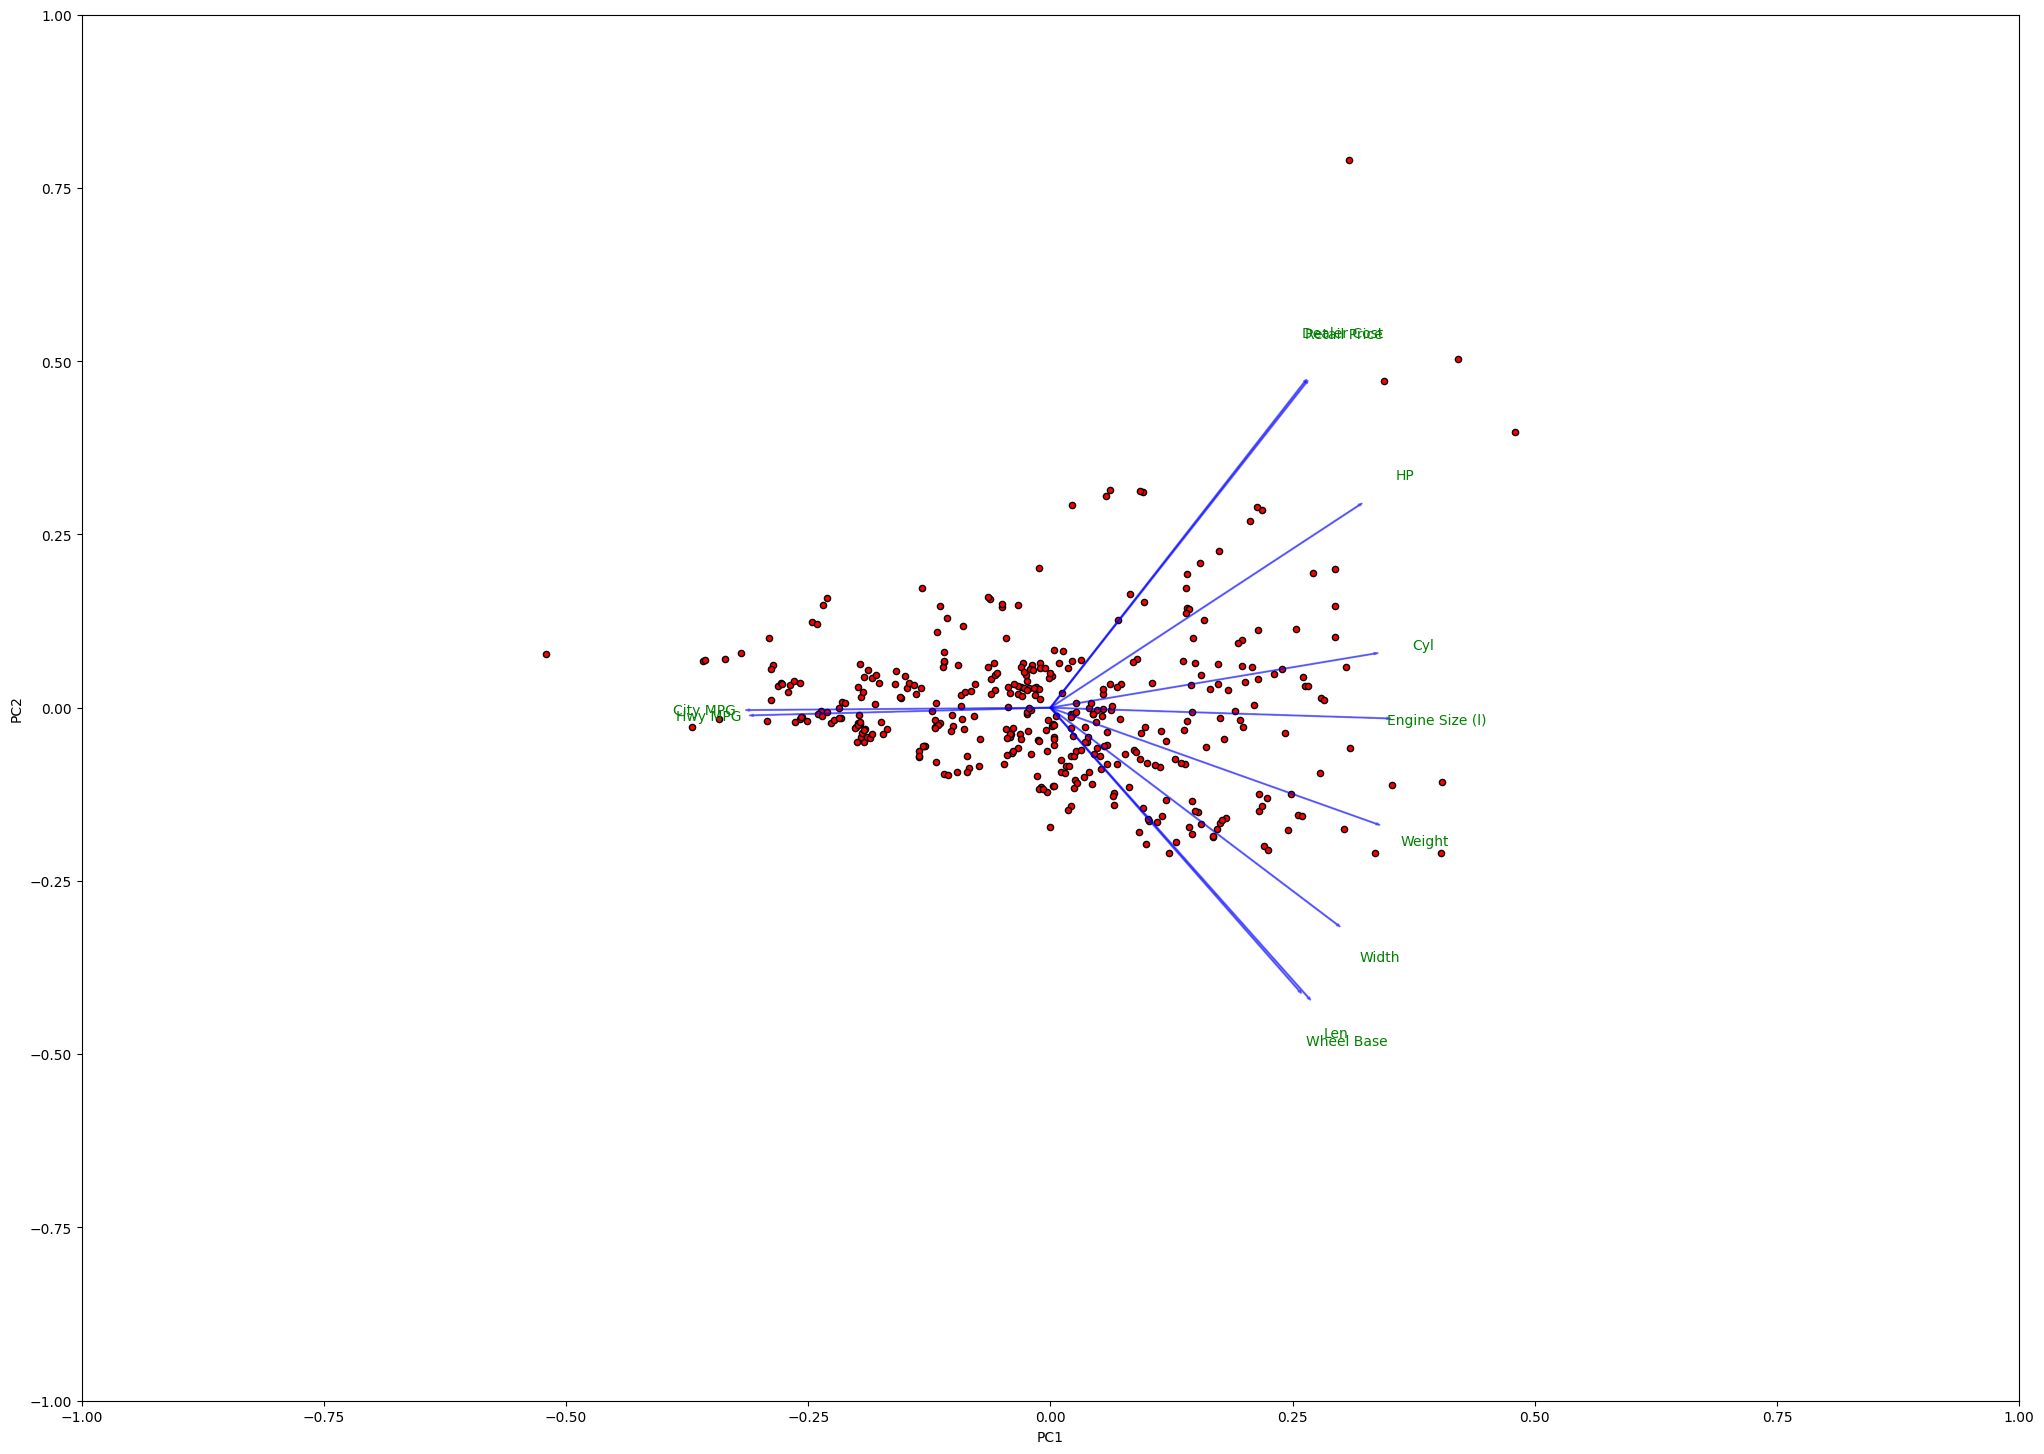

In [70]:
biplot(X_pca, np.transpose(pca.components_[0:2, :]), labels=attributes)